# Benchmarking – Baseline Simulation Studies:
## 1) Imports and Set-Up:

### 1.1) Imports & Seed-Setting:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
%env PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning

env: PYTHONWARNINGS=ignore::FutureWarning,ignore::DeprecationWarning,ignore::UserWarning,ignore::RuntimeWarning


### 1.2) Helper-Functions:

In [3]:
from pathlib import Path
import json

from benchmarks._artifacts import read_run, read_runtimes
from benchmarks._registry import SCENARIOS
from benchmarks._tables import summarize
from benchmarks.figures import (
    figure_benchmarking_examples,
    figure_benchmarking_results,
    figure_scaling_ari,
    figure_scaling_runtime,
    figure_scenario_overview,
)
from benchmarks.tables import table_metrics, write_all_tables

RESULTS_ROOT = Path("../results/runs")

# Columns worth reading per scenario. The full summarize() frame carries
# seventeen, most of which only matter to the manuscript tables.
SUMMARY_COLUMNS = ["axis_label", "display_name", "ari_mean", "ari_sd", "k_recovery"]


def run_dir(name):
    """Return the widest sweep available for a scenario.

    Run directories are named by configuration hash, so sorting them
    lexically picks an arbitrary one when a scenario has been run at more
    than one scale. Selecting on the manifest's sweep size instead means a
    reduced exploratory run never silently shadows a full one.
    """
    runs = sorted(p for p in (RESULTS_ROOT / name).glob("*/") if p.is_dir())
    if not runs:
        raise FileNotFoundError(
            f"No run for {name!r}. Produce one with: "
            f"python -m benchmarks.run --scenario {name}"
        )

    def sweep_size(rd):
        manifest = json.loads((rd / "manifest.json").read_text())
        return (manifest["n_seeds"], manifest["n_resamples"])

    return max(runs, key=sweep_size)


def load(name):
    """Read the widest available run for a scenario."""
    return read_run(run_dir(name))


def scenario_report(name):
    """Report a scenario's sweep size, then its per-axis summary.

    One row per (axis label, method), computed from the k each method
    selected. This is the same computation behind the manuscript's S2 to S9
    tables, trimmed to the columns worth reading inline.
    """
    rd = run_dir(name)
    manifest = json.loads((rd / "manifest.json").read_text())
    print(
        f"{name}: {manifest['n_seeds']} seeds x {manifest['n_resamples']} resamples "
        f"(run {rd.name})"
    )
    table = summarize(read_run(rd), metrics=table_metrics())
    return table[SUMMARY_COLUMNS]


def show(fig):
    """Display a figure exactly once, then close it.

    A figure left open is rendered by the inline backend's end-of-cell
    flush, and a figure returned from a cell is rendered as that cell's
    result. A helper that does both renders twice in some cells and once in
    others. Displaying explicitly and closing is the one path that draws
    every figure exactly once.
    """
    display(fig)
    plt.close(fig)


def scenario_overview(name):
    """Draw one family's section figure: example datasets over its ARI curve.

    The lower panel carries the same series as Fig 4 in section 4, read from
    the same artifact, so a section and the combined figure cannot disagree.
    """
    show(figure_scenario_overview(name, load(name)))


---

## 2) Difficulty Scenarios:

Each scenario below reports its example datasets at the three difficulty
anchors, ARI at the k its method selected against difficulty, and a summary
table with the standard deviation across seeds and the k-recovery rate.

Compute runs headless. Produce artifacts with `python -m benchmarks.run --all`,
then re-run this notebook, which only reads them.

### 2.1) Gaussian Mixtures:

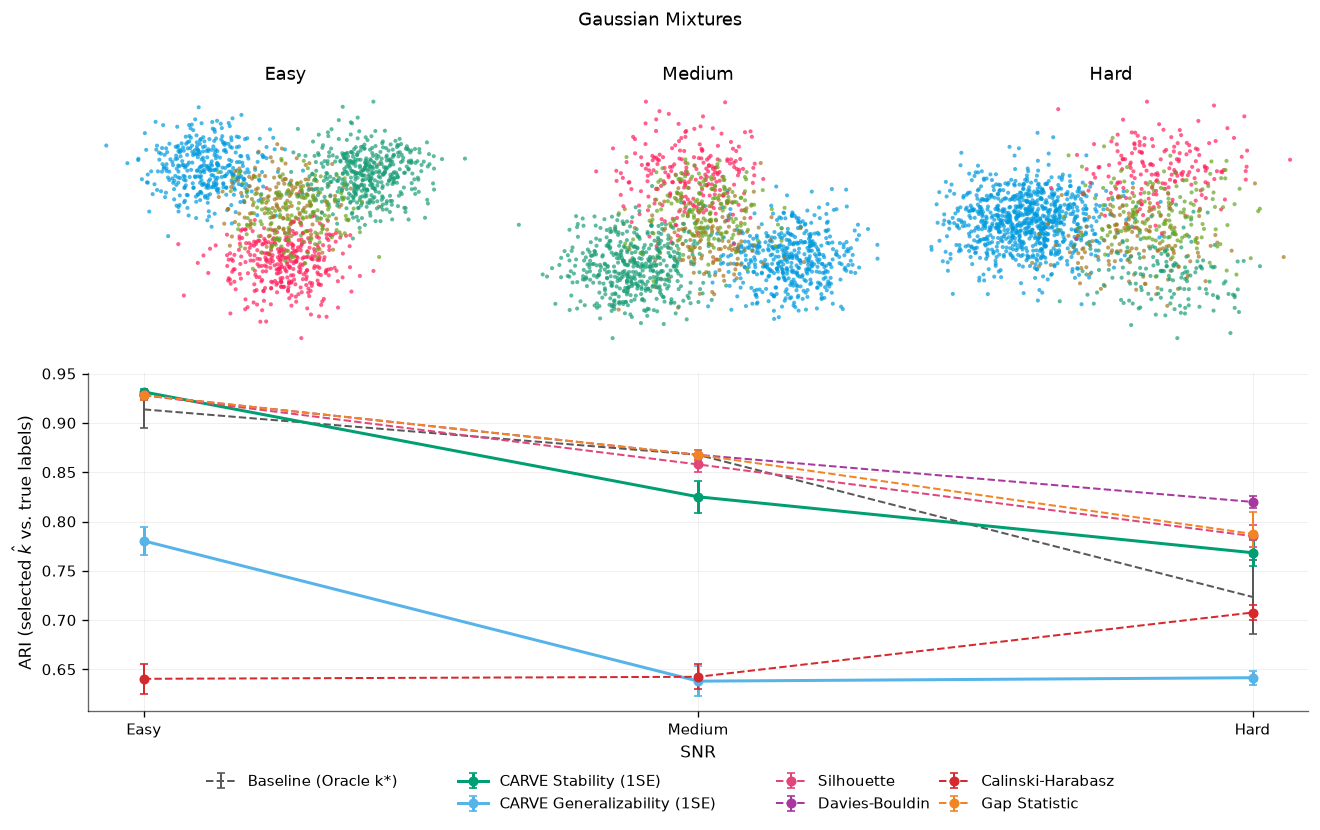

In [4]:
scenario_overview("gaussians")

In [5]:
scenario_report("gaussians")

gaussians: 20 seeds x 100 resamples (run c26e5c9adbe7)


,axis_label,display_name,ari_mean,ari_sd,k_recovery
0,easy,Baseline (Oracle),0.914,0.084,NaN
1,easy,Accuracy (gen),0.750,0.094,0.45
2,easy,"ARI (gen, max)",0.777,0.066,0.55
3,easy,CARVE Generalizability (1SE),0.780,0.063,0.55
4,easy,"ARI (gen, quantile)",0.795,0.039,0.95
5,easy,"ARI (stab, max)",0.932,0.015,1.00
6,easy,CARVE Stability (1SE),0.932,0.015,1.00
7,easy,"ARI (stab, quantile)",0.932,0.015,1.00
8,easy,Gini (stab),0.927,0.020,0.95
9,easy,Silhouette,0.928,0.023,0.95


### 2.2) t-Distributed Mixtures:

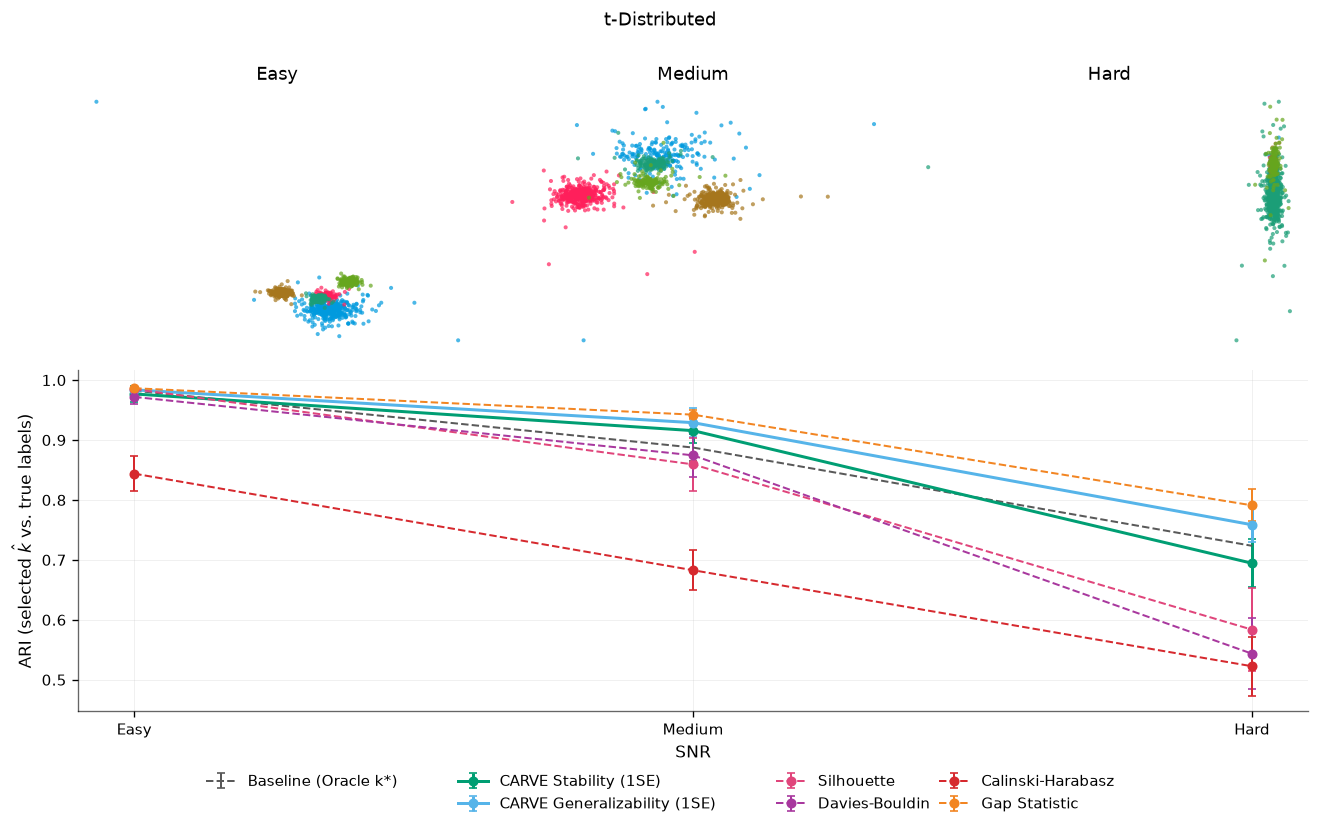

In [6]:
scenario_overview("t_dist")

In [7]:
scenario_report("t_dist")

t_dist: 20 seeds x 100 resamples (run fc5c68fd962a)


,axis_label,display_name,ari_mean,ari_sd,k_recovery
0,easy,Baseline (Oracle),0.983,0.021,NaN
1,easy,Accuracy (gen),0.910,0.133,0.50
2,easy,"ARI (gen, max)",0.984,0.020,0.65
3,easy,CARVE Generalizability (1SE),0.984,0.020,0.55
4,easy,"ARI (gen, quantile)",0.988,0.006,0.00
5,easy,"ARI (stab, max)",0.948,0.105,0.50
6,easy,CARVE Stability (1SE),0.977,0.061,0.45
7,easy,"ARI (stab, quantile)",0.990,0.004,0.00
8,easy,Gini (stab),0.991,0.005,0.65
9,easy,Silhouette,0.985,0.008,0.00


### 2.3) t-Distributed Mixtures with Noise Dimensions:

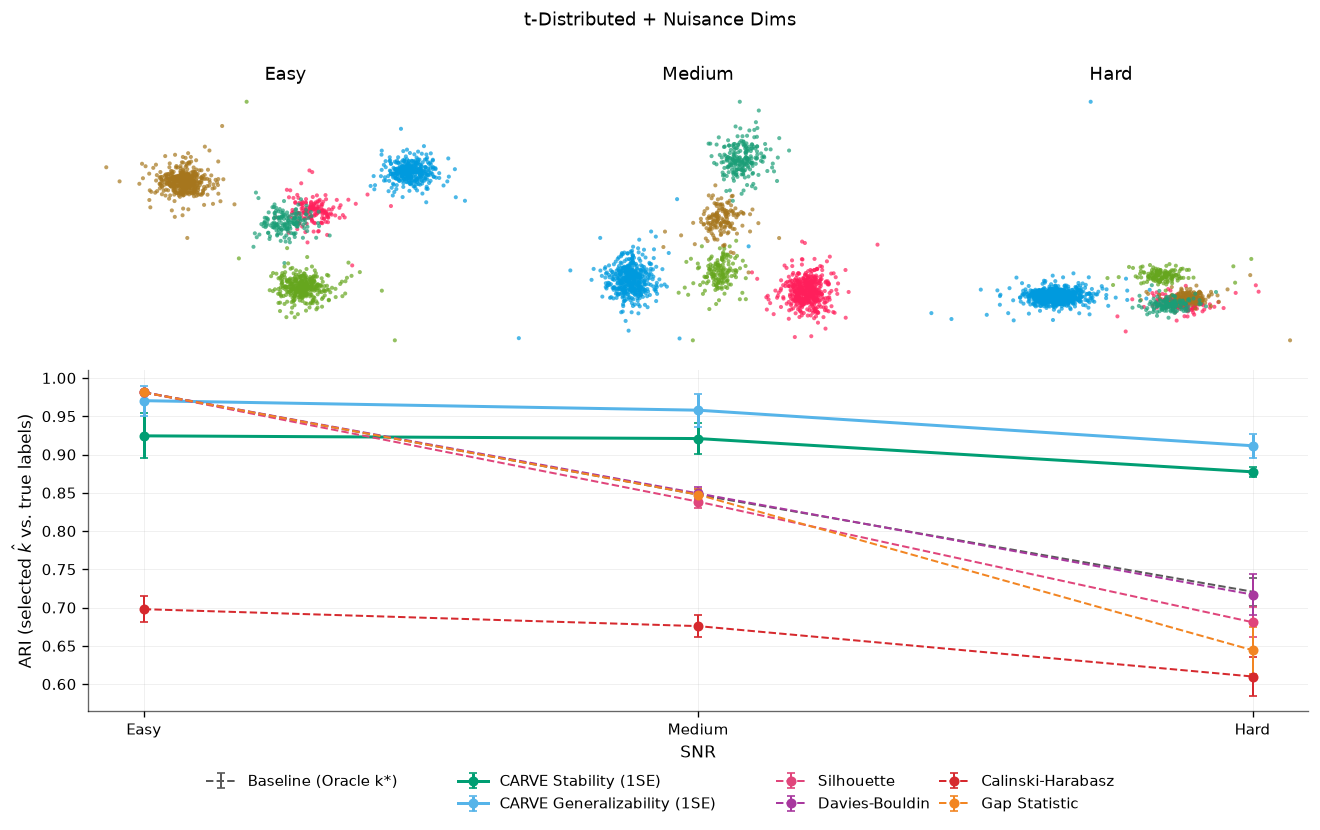

In [8]:
scenario_overview("t_dist_noise")

In [9]:
scenario_report("t_dist_noise")

t_dist_noise: 20 seeds x 100 resamples (run 238e63ba00f7)


,axis_label,display_name,ari_mean,ari_sd,k_recovery
0,easy,Baseline (Oracle),0.981,0.007,NaN
1,easy,Accuracy (gen),0.904,0.122,0.55
2,easy,"ARI (gen, max)",0.950,0.104,0.80
3,easy,CARVE Generalizability (1SE),0.970,0.087,0.90
4,easy,"ARI (gen, quantile)",0.998,0.002,1.00
5,easy,"ARI (stab, max)",0.883,0.148,0.55
6,easy,CARVE Stability (1SE),0.925,0.132,0.75
7,easy,"ARI (stab, quantile)",0.994,0.003,1.00
8,easy,Gini (stab),0.974,0.089,0.95
9,easy,Silhouette,0.981,0.007,0.85


### 2.4) Concentric Circles:

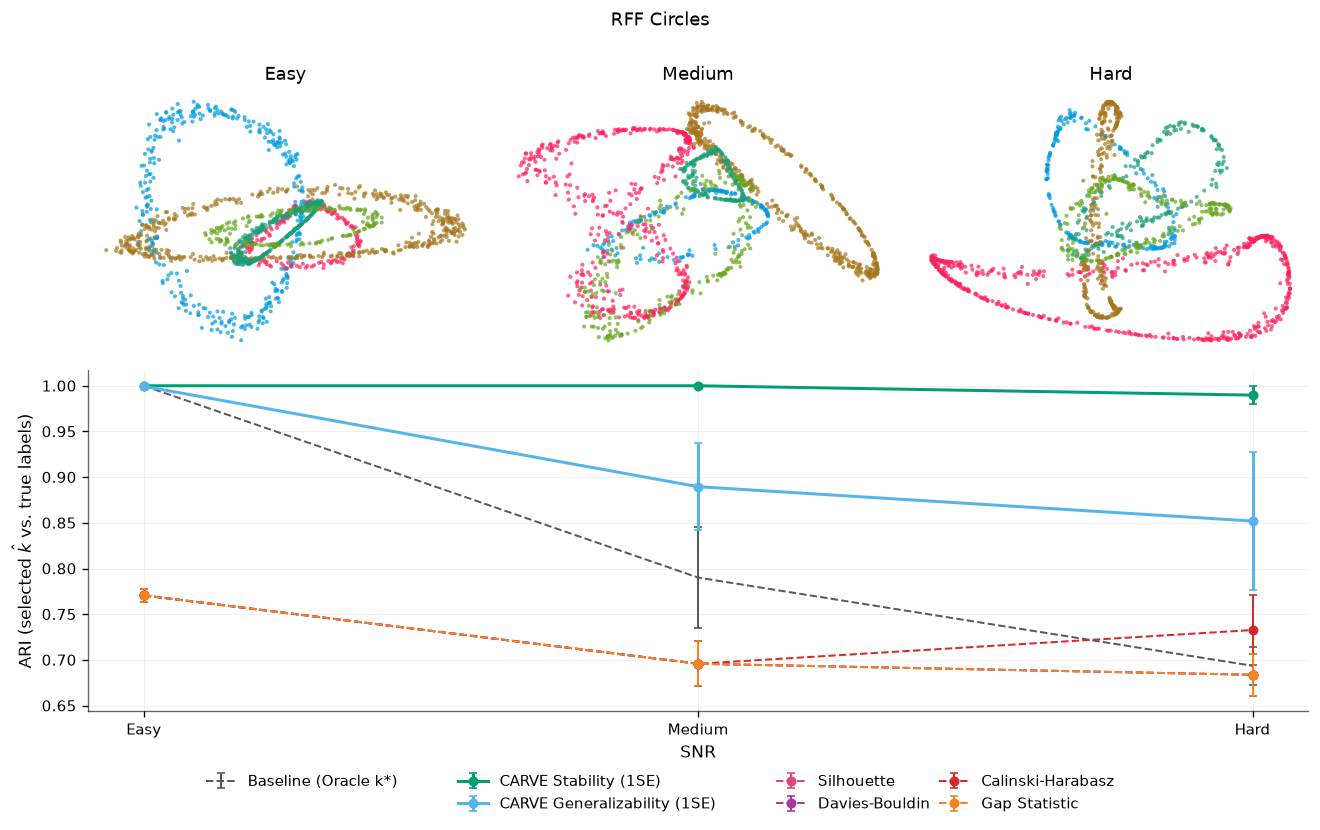

In [10]:
scenario_overview("circles")

In [11]:
scenario_report("circles")

circles: 5 seeds x 20 resamples (run 6097a217cc2b)


,axis_label,display_name,ari_mean,ari_sd,k_recovery
0,easy,Baseline (Oracle),1.000,0.000,NaN
1,easy,Accuracy (gen),0.999,0.001,1.0
2,easy,"ARI (gen, max)",0.999,0.001,1.0
3,easy,CARVE Generalizability (1SE),0.999,0.001,1.0
4,easy,"ARI (gen, quantile)",0.999,0.001,1.0
5,easy,"ARI (stab, max)",1.000,0.000,1.0
6,easy,CARVE Stability (1SE),1.000,0.000,1.0
7,easy,"ARI (stab, quantile)",1.000,0.000,1.0
8,easy,Gini (stab),1.000,0.000,1.0
9,easy,Silhouette,0.771,0.016,0.0


### 2.5) Moons:

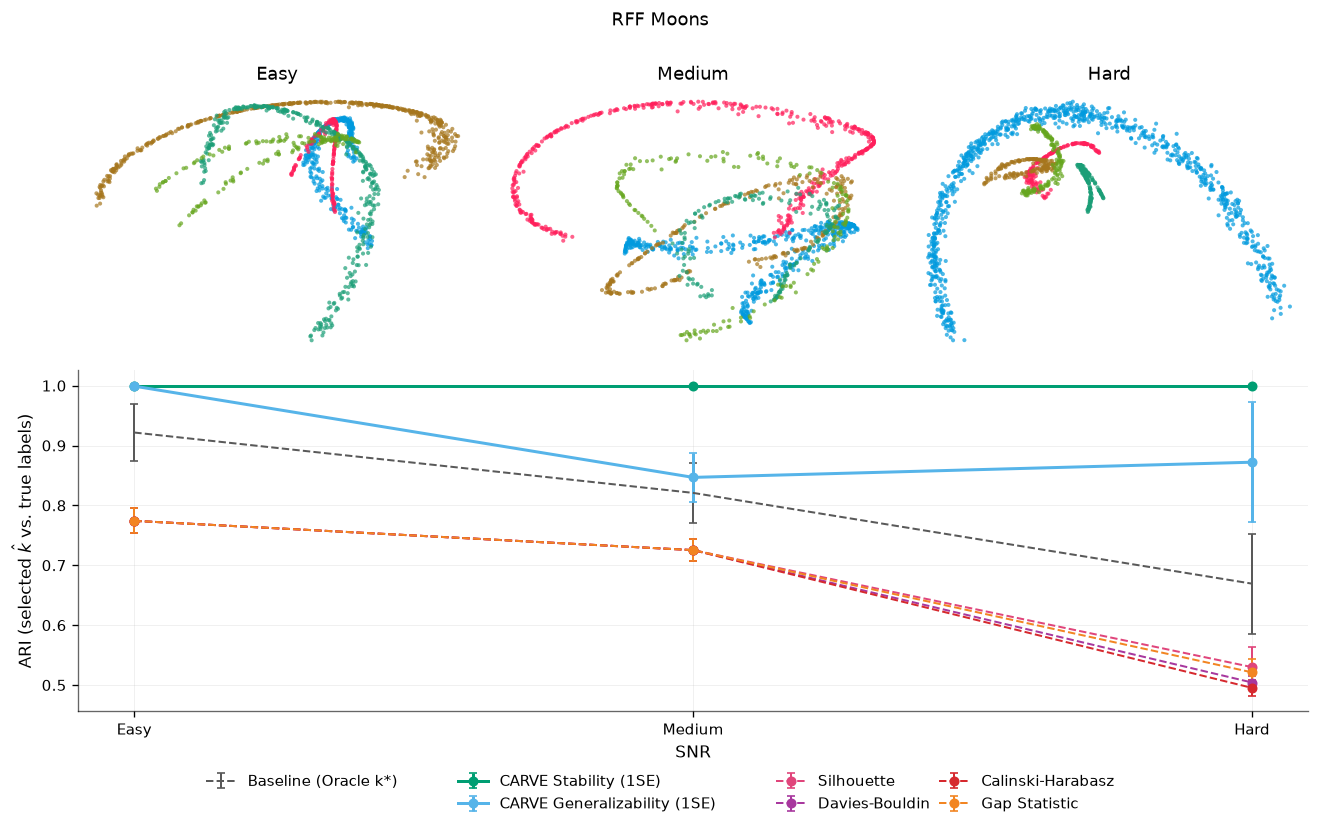

In [12]:
scenario_overview("moons")

In [13]:
scenario_report("moons")

moons: 5 seeds x 20 resamples (run d3f5acd783ec)


,axis_label,display_name,ari_mean,ari_sd,k_recovery
0,easy,Baseline (Oracle),0.922,0.107,NaN
1,easy,Accuracy (gen),0.999,0.001,1.0
2,easy,"ARI (gen, max)",0.999,0.001,1.0
3,easy,CARVE Generalizability (1SE),0.999,0.001,1.0
4,easy,"ARI (gen, quantile)",0.955,0.100,0.8
5,easy,"ARI (stab, max)",1.000,0.000,1.0
6,easy,CARVE Stability (1SE),1.000,0.000,1.0
7,easy,"ARI (stab, quantile)",1.000,0.000,1.0
8,easy,Gini (stab),0.977,0.052,0.8
9,easy,Silhouette,0.774,0.046,0.0


### 2.6) Swiss Rolls:

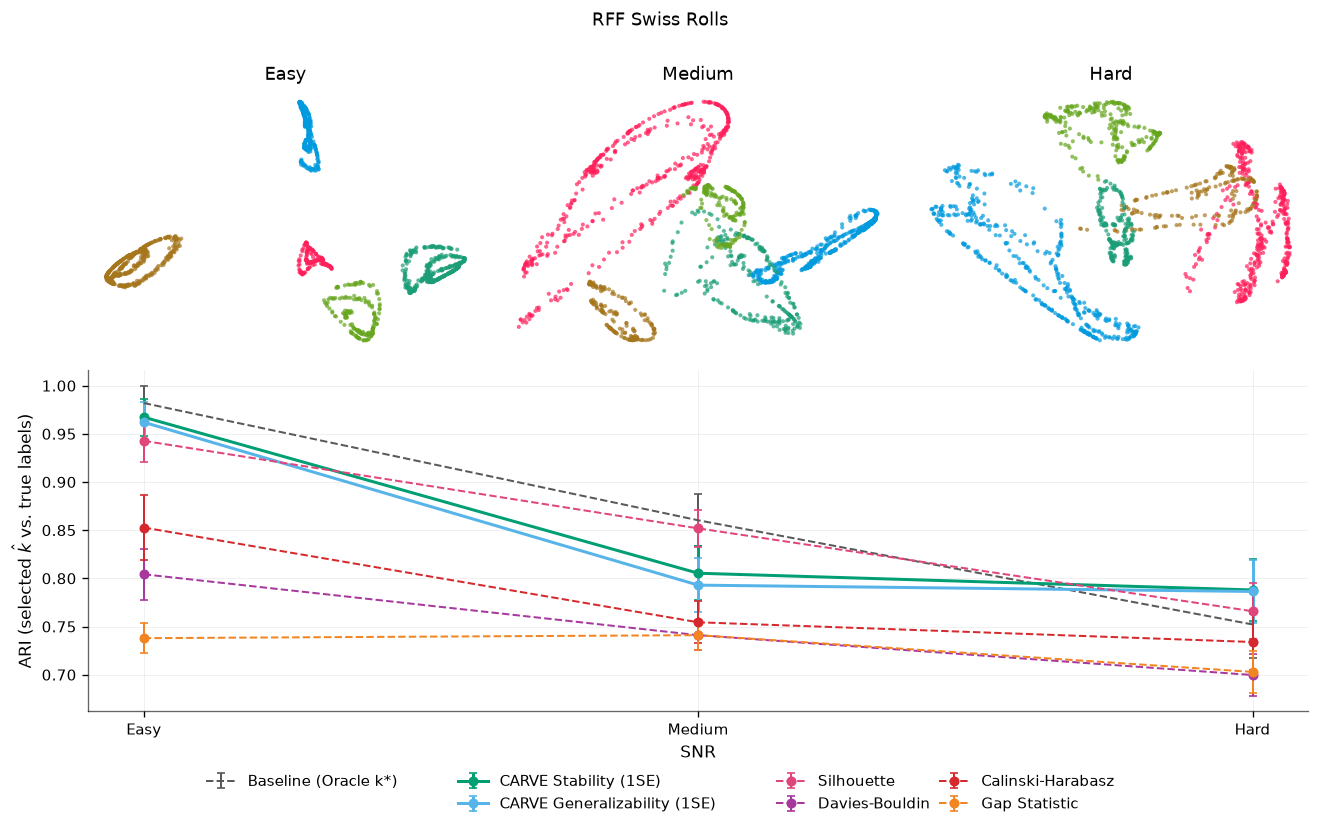

In [14]:
scenario_overview("swiss_rolls")

In [15]:
scenario_report("swiss_rolls")

swiss_rolls: 20 seeds x 100 resamples (run aec865707105)


,axis_label,display_name,ari_mean,ari_sd,k_recovery
0,easy,Baseline (Oracle),0.982,0.080,NaN
1,easy,Accuracy (gen),0.932,0.097,0.55
2,easy,"ARI (gen, max)",0.932,0.097,0.55
3,easy,CARVE Generalizability (1SE),0.962,0.092,0.80
4,easy,"ARI (gen, quantile)",0.948,0.106,0.75
5,easy,"ARI (stab, max)",0.890,0.126,0.45
6,easy,CARVE Stability (1SE),0.967,0.086,0.80
7,easy,"ARI (stab, quantile)",0.952,0.104,0.75
8,easy,Gini (stab),0.876,0.128,0.40
9,easy,Silhouette,0.943,0.099,0.70


---

## 3) Scaling Scenarios

These two sweep an axis other than difficulty, so their overviews are read
against that axis rather than against easy/medium/hard. Runtime is reported
separately in the scaling figures in section 4.

### 3.1) Gaussian Mixtures over Feature Dimension:

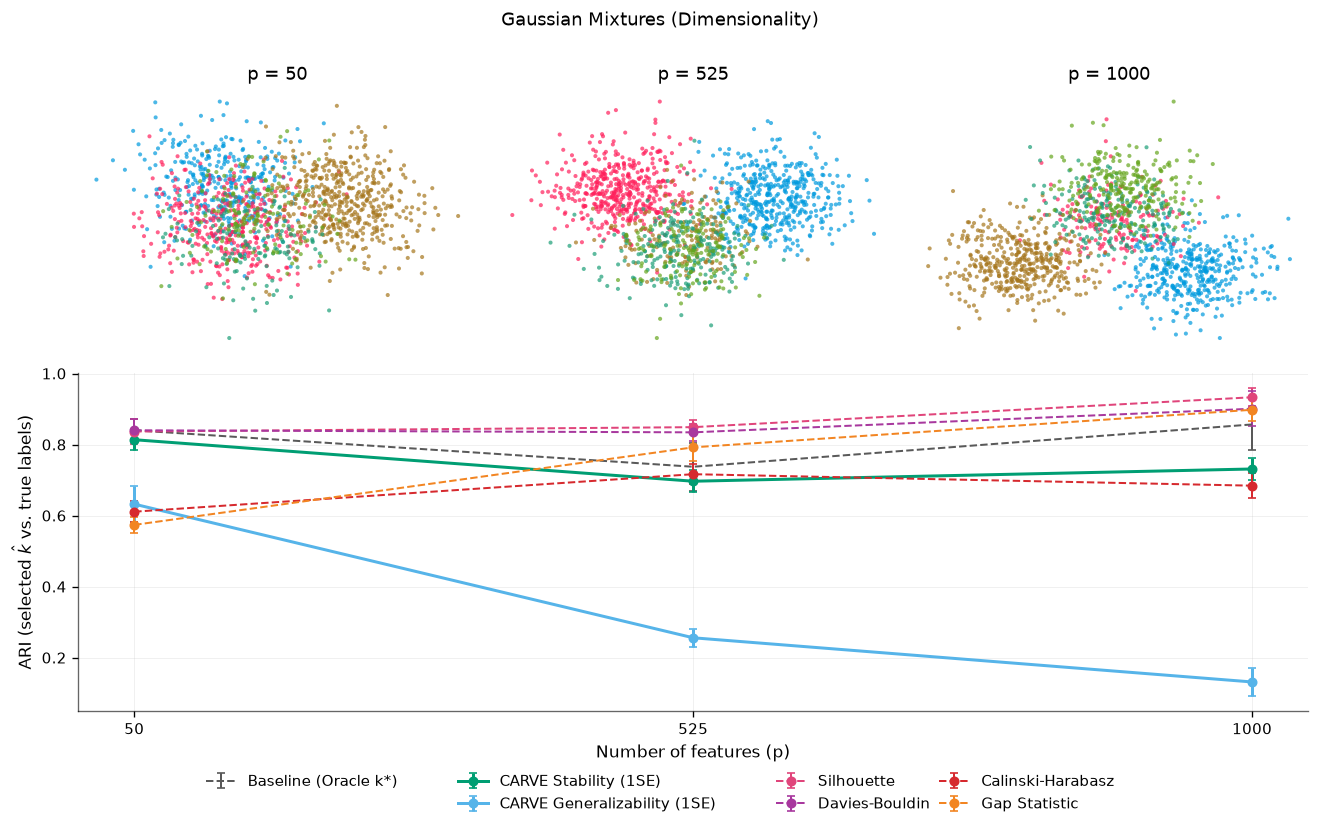

In [16]:
scenario_overview("gaussians_dimensionality")

In [17]:
scenario_report("gaussians_dimensionality")

gaussians_dimensionality: 5 seeds x 20 resamples (run 3510e2da7e25)


,axis_label,display_name,ari_mean,ari_sd,k_recovery
0,start,Baseline (Oracle),0.840,0.070,NaN
1,start,Accuracy (gen),0.618,0.125,0.2
2,start,"ARI (gen, max)",0.633,0.111,0.2
3,start,CARVE Generalizability (1SE),0.633,0.111,0.2
4,start,"ARI (gen, quantile)",0.691,0.019,0.6
5,start,"ARI (stab, max)",0.814,0.064,0.6
6,start,CARVE Stability (1SE),0.814,0.064,0.6
7,start,"ARI (stab, quantile)",0.794,0.101,0.4
8,start,Gini (stab),0.814,0.064,0.6
9,start,Silhouette,0.837,0.076,0.8


### 3.2) Gaussian Mixtures over Sample Size:

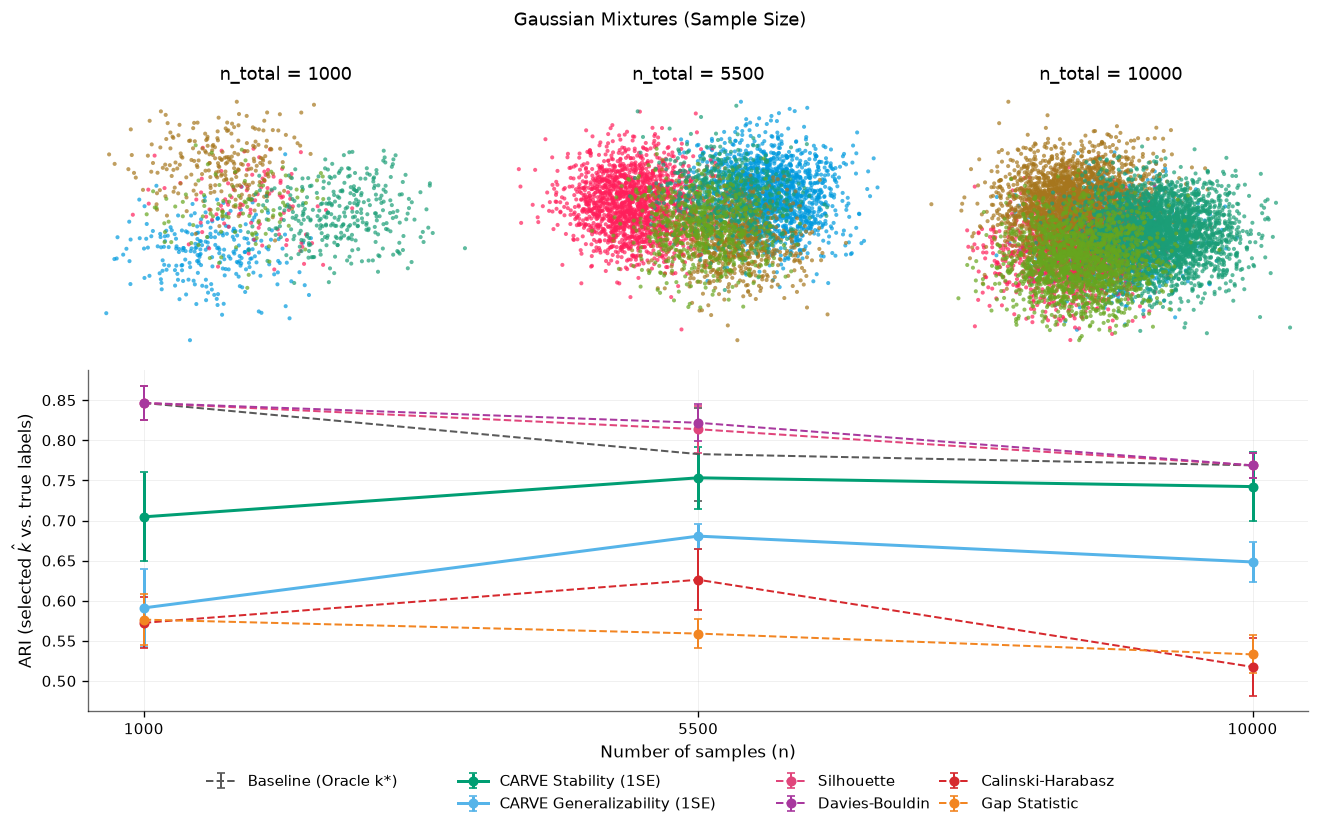

In [18]:
scenario_overview("gaussians_samples")

In [19]:
scenario_report("gaussians_samples")

gaussians_samples: 5 seeds x 20 resamples (run 0e4783847e43)


,axis_label,display_name,ari_mean,ari_sd,k_recovery
0,start,Baseline (Oracle),0.847,0.048,NaN
1,start,Accuracy (gen),0.591,0.108,0.2
2,start,"ARI (gen, max)",0.591,0.108,0.2
3,start,CARVE Generalizability (1SE),0.591,0.108,0.2
4,start,"ARI (gen, quantile)",0.629,0.085,0.2
5,start,"ARI (stab, max)",0.674,0.104,0.2
6,start,CARVE Stability (1SE),0.705,0.124,0.2
7,start,"ARI (stab, quantile)",0.708,0.180,0.6
8,start,Gini (stab),0.684,0.156,0.2
9,start,Silhouette,0.847,0.048,1.0


---

## 4) Combined Figures and Manuscript Tables

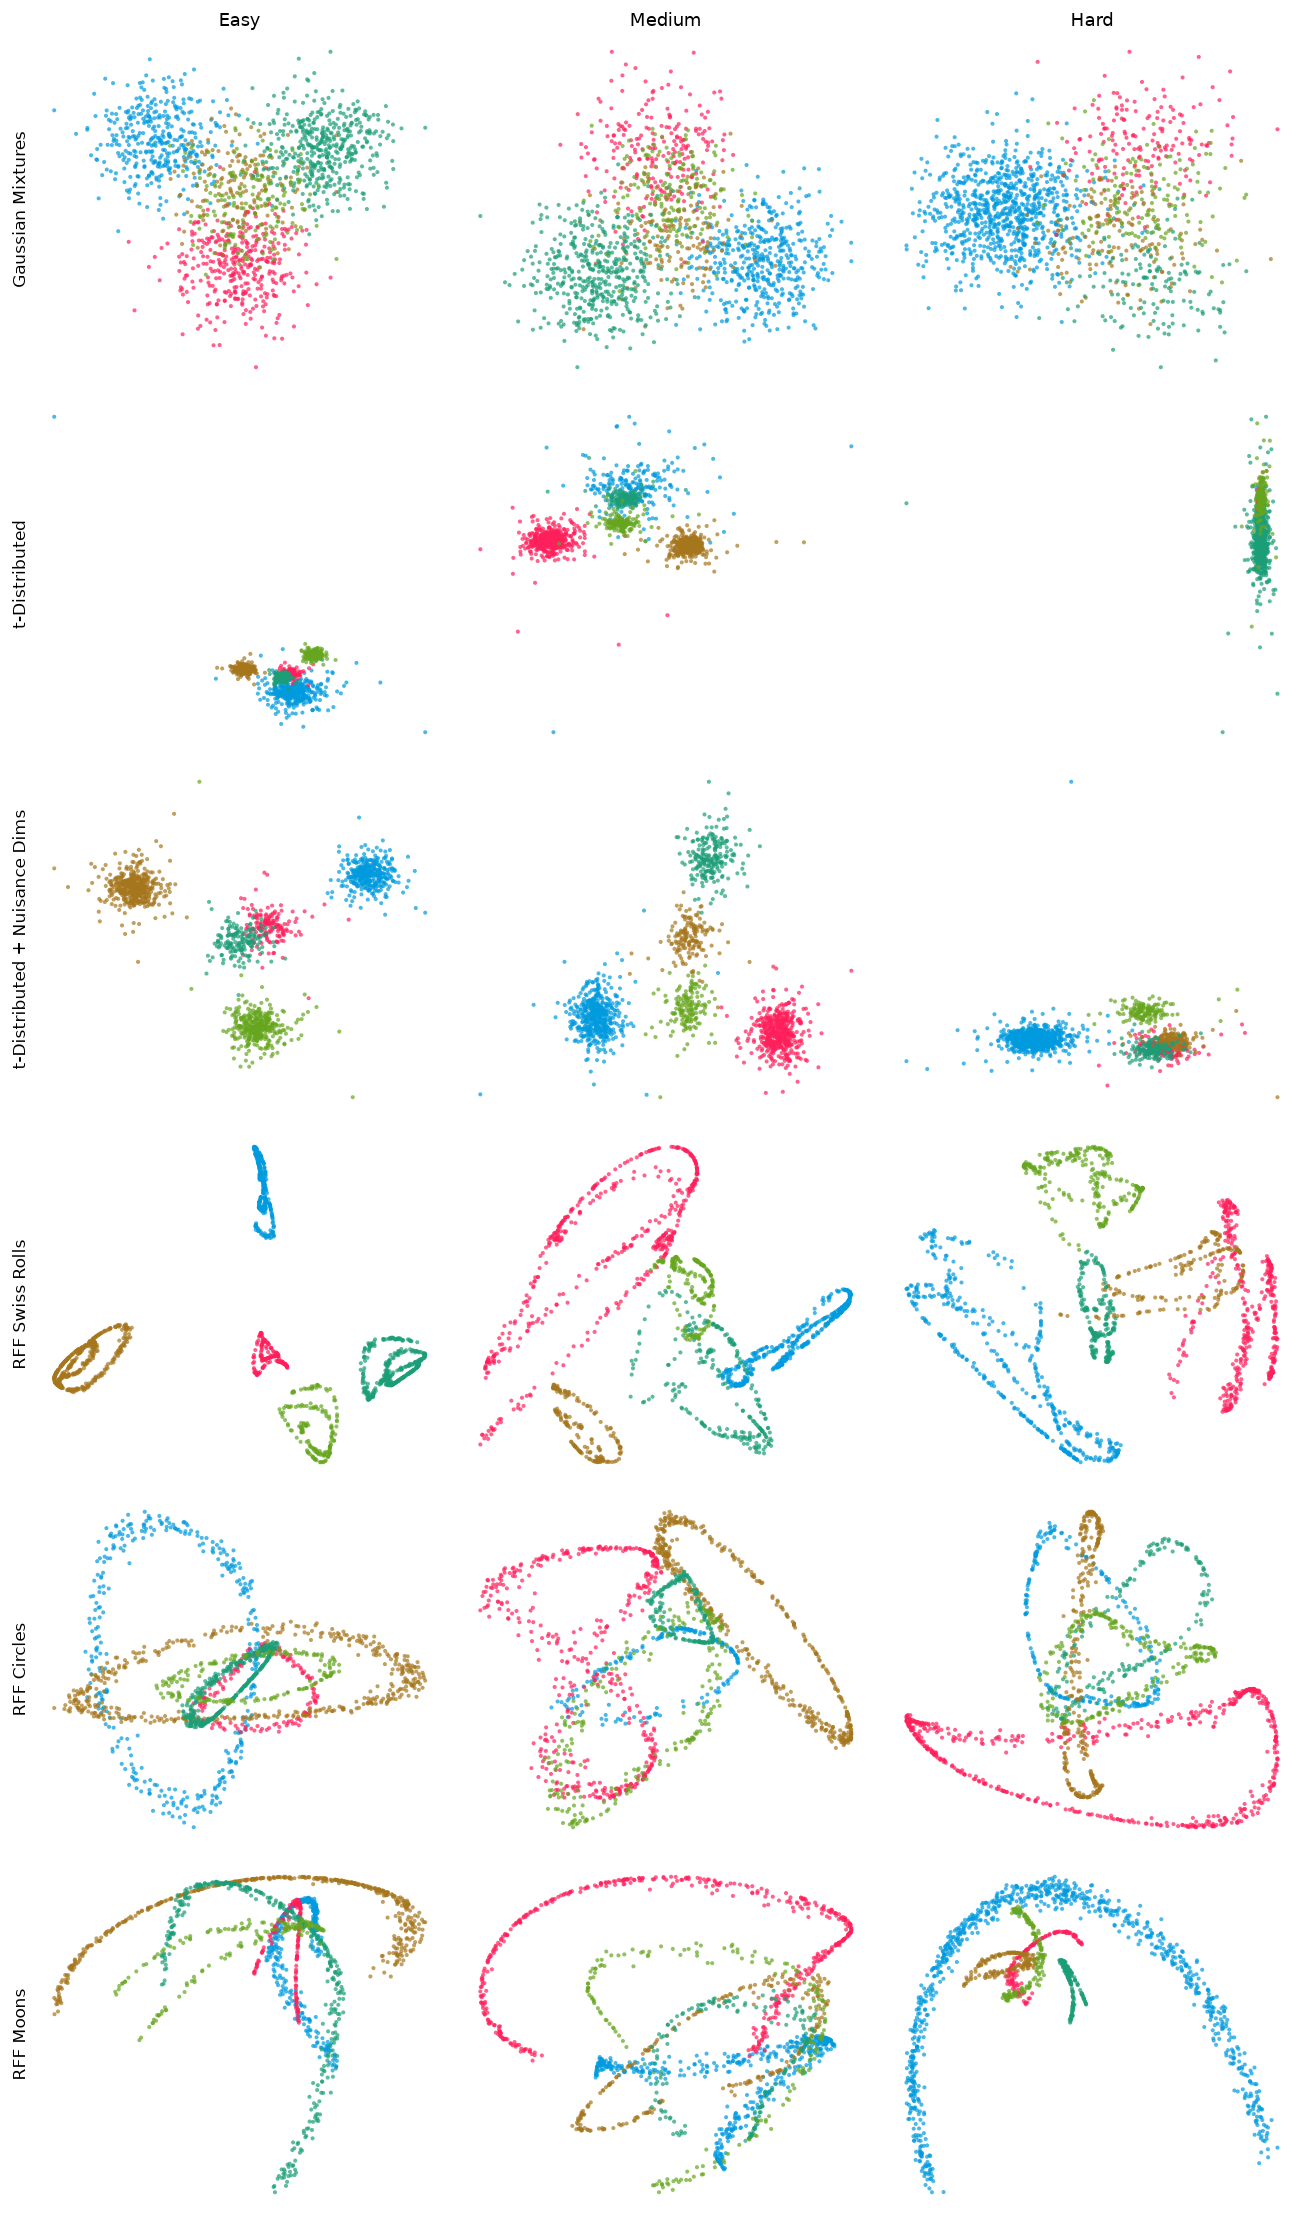

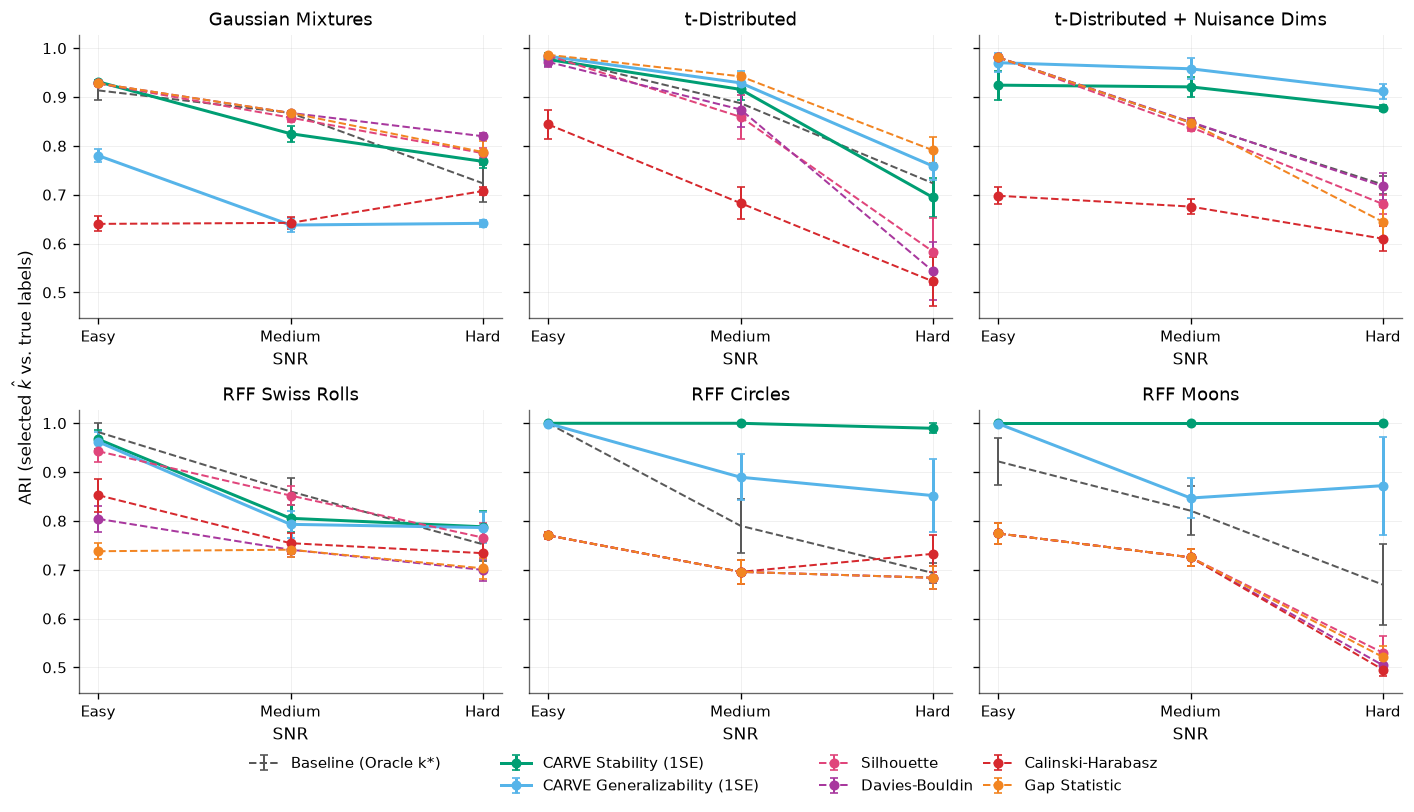

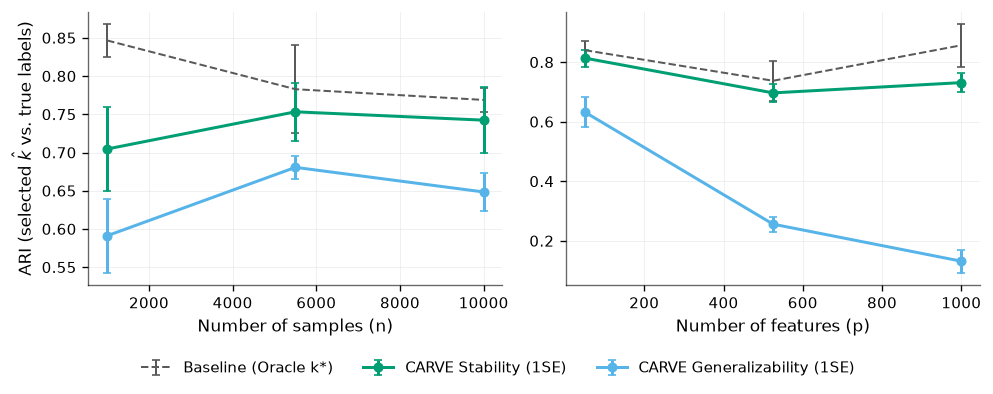

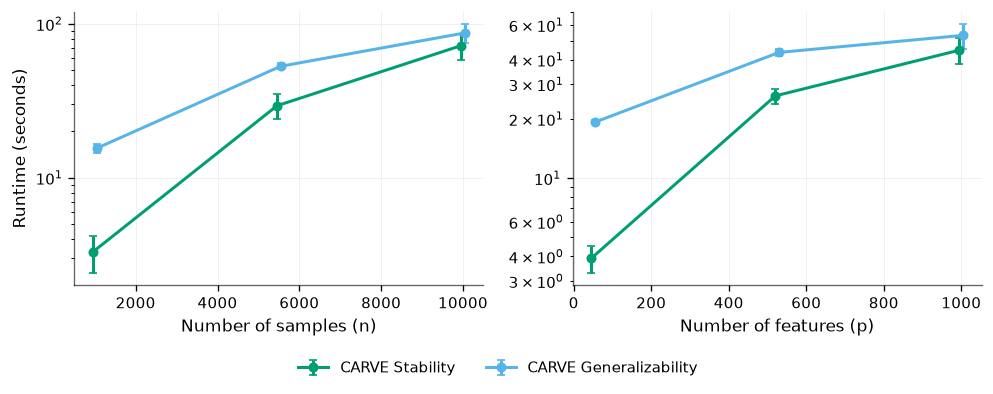

[PosixPath('../vis/tables/S2_table.tex'),
 PosixPath('../vis/tables/S3_table.tex'),
 PosixPath('../vis/tables/S4_table.tex'),
 PosixPath('../vis/tables/S5_table.tex'),
 PosixPath('../vis/tables/S6_table.tex'),
 PosixPath('../vis/tables/S7_table.tex'),
 PosixPath('../vis/tables/S9_table.tex'),
 PosixPath('../vis/tables/S8_table.tex')]

In [20]:
results = {name: load(name) for name in SCENARIOS}

difficulty = {
    k: v for k, v in results.items() if v["axis_name"].iloc[0] == "difficulty_level"
}
scaling = {
    k: v for k, v in results.items() if v["axis_name"].iloc[0] != "difficulty_level"
}
runtimes = {name: read_runtimes(run_dir(name)) for name in scaling}

# Each of these writes itself under its manuscript filename in vis/
# benchmarking/. Copying one into overleaf/vis/ stays a manual step.
show(figure_benchmarking_examples())
show(figure_benchmarking_results(difficulty))
show(figure_scaling_ari(scaling))
show(figure_scaling_runtime(runtimes))

write_all_tables(results, Path("../vis/tables"))


---